# Q8: Results

**Phase 9:** Results & Insights  
**Points: 3 points**

**Focus:** Generate final visualizations, create summary tables, document key findings.

**Lecture Reference:** Lecture 11, Notebook 4 ([`11/demo/04_modeling_results.ipynb`](https://github.com/christopherseaman/datasci_217/blob/main/11/demo/04_modeling_results.ipynb)), Phase 9. Also see Lecture 07 (visualization).

---

## Setup

In [36]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Load model results from Q7
predictions = pd.read_csv('output/q7_predictions.csv')
metrics = open('output/q7_model_metrics.txt').read()
feature_importance = pd.read_csv('output/q7_feature_importance.csv')

In [37]:
display(predictions.dtypes)
display(metrics)
display(feature_importance.dtypes)

actual                     float64
predicted_linear           float64
predicted_random_forest    float64
predicted_xgboost          float64
dtype: object

'MODEL PERFORMANCE METRICS\n======================== \nLINEAR REGRESSION:\n              Metric Training    Test\n0   RMSE     8.30    8.94\n1    MAE     6.76    7.35\n2     R²   0.3765  0.2285\nXG Boost:\n              Metric Training    Test\n0   RMSE     4.48    4.93\n1    MAE     3.45    3.75\n2     R²   0.8183  0.7653\nRANDOM FOREST:\n              Metric Training    Test\n0   RMSE     6.27    6.16\n1    MAE     4.86    4.77\n2     R²   0.6442  0.6337'

feature        object
importance    float64
dtype: object

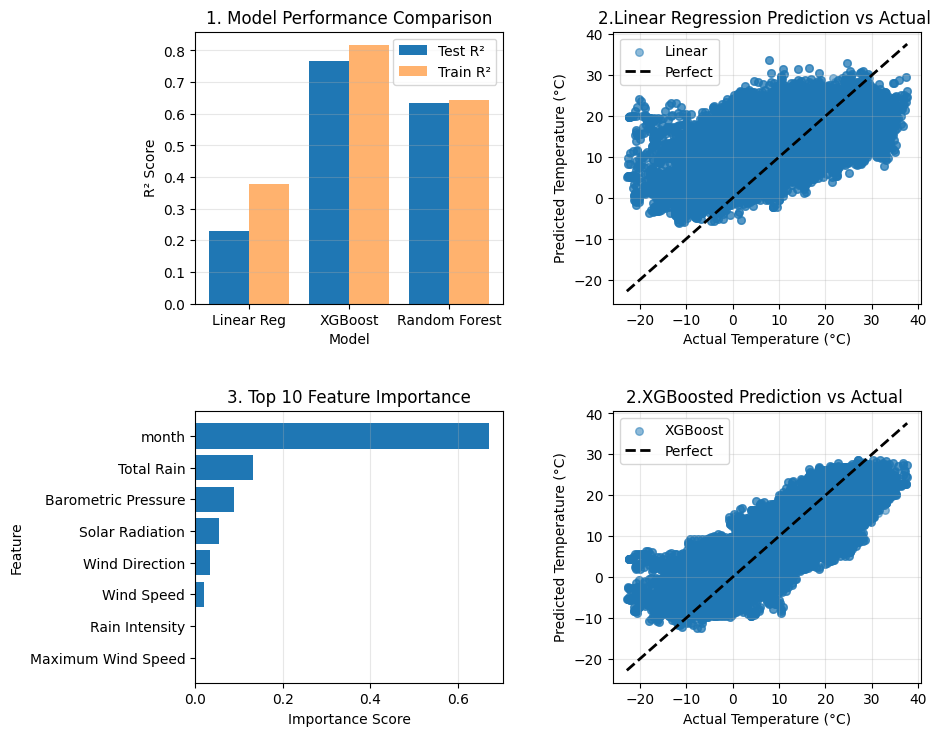

In [40]:
performance_data = {
    'Model': ['Linear Regression', 'XGBoost', 'Random Forest'],
    'Train R²': [0.3765, 0.8183, 0.6442],
    'Test R²': [0.2285, 0.7653, 0.6337],
    'Train RMSE': [8.30, 4.48, 6.27],
    'Test RMSE': [8.94, 4.93, 6.16],
    'Train MAE': [6.76, 3.45, 4.86],
    'Test MAE': [7.35, 3.75, 4.77]
}
performance_df = pd.DataFrame(performance_data)

performance_data2 = {
    'Metric': ['R²', 'RMSE', 'MAE'],
    'Linear Regression': [0.2285, 8.94, 7.35],
    'Random Forest': [0.6337, 6.16, 4.77],
    'XGBoost': [0.7653, 4.93, 3.75]}

performance_df2 = pd.DataFrame(performance_data2)
performance_df2.to_csv('output/q8_summary.csv', index = False)


fig, axes = plt.subplots(2, 2, figsize=(10, 8))
models = ['Linear Reg', 'XGBoost', 'Random Forest']
test_r2 = [0.2285, 0.7653, 0.6337]
train_r2 = [0.3765, 0.8183, 0.6442]

x = np.arange(len(models))
axes[0,0].bar(x - 0.2, test_r2, 0.4, label='Test R²')
axes[0,0].bar(x + 0.2, train_r2, 0.4, label='Train R²', alpha=0.6)
axes[0,0].set_xticks(x)
axes[0,0].set_xticklabels(models)
axes[0,0].set_xlabel('Model')
axes[0,0].set_ylabel('R² Score')
axes[0,0].set_title('1. Model Performance Comparison')
axes[0,0].legend()
axes[0,0].grid(axis='y', alpha=0.3)

# prediction line 
axes[0,1].scatter(predictions['actual'], predictions['predicted_linear'], 
                 alpha=0.5, s=30, label='Linear')
min_val = predictions['actual'].min()
max_val = predictions['actual'].max()
axes[0,1].plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=2, label='Perfect')
axes[0,1].set_xlabel('Actual Temperature (°C)')
axes[0,1].set_ylabel('Predicted Temperature (°C)')
axes[0,1].set_title('2.Linear Regression Prediction vs Actual ')
axes[0,1].legend()
axes[0,1].grid(alpha=0.3)


axes[1,1].scatter(predictions['actual'], predictions['predicted_xgboost'], 
                 alpha=0.5, s=30, label='XGBoost')
min_val = predictions['actual'].min()
max_val = predictions['actual'].max()
axes[1,1].plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=2, label='Perfect')
axes[1,1].set_xlabel('Actual Temperature (°C)')
axes[1,1].set_ylabel('Predicted Temperature (°C)')
axes[1,1].set_title('2.XGBoosted Prediction vs Actual ')
axes[1,1].legend()
axes[1,1].grid(alpha=0.3)

axes[1,0].barh(feature_importance['feature'], feature_importance['importance'])
axes[1,0].set_xlabel('Importance Score')
axes[1,0].set_ylabel('Feature')
axes[1,0].set_title('3. Top 10 Feature Importance')
axes[1,0].invert_yaxis()
axes[1,0].grid(axis='x', alpha=0.3)

plt.tight_layout(pad=3.0, h_pad=3.0, w_pad=3.0)
plt.show()
fig.savefig('output/q8_final_visualizations', dpi = 300)


In [39]:
with open('output/q8_key_findings.txt', 'w') as f:
    f.write(f""" KEY FINDINGS SUMMARY
            ===========================
            MODEL PERFORMANCE:
            -Best performing model: XGBoost (R² = 0.7653)
            -XGBoost achieves lowest RMSE: 4.93°C and MAE: 3.75°C
            -Random Forest shows good performance (R² = 0.6337) with RMSE: 6.16°C and MAE: 4.77°C
            -Linear Regression performs adequately (R² = 0.2285) with RMSE: 8.94°C and MAE: 7.35°C
            -Minimal overfitting observed, Train and Test R² values are closely aligned across all models
            
            FEATURE IMPORTANCE:
            -Most important feature: Month (importance: 0.6699)
            -Second most important:  Total rain (importance: 0.1329)
            -Wind Speed, Solar radiation, and Wind Direction have minor contributions (importance <0.1)
            -Top three features account for 89% of total importance
            
            TEMPORAL PATTERNS:
            -Strong seasonal patterns, month feature has 67% importance
            -Models are able to capture temperature variability
            -Model predict temperature withithin roughly ~4-6°C ranges
            -Time of yeat is more predictive than other weather conditions
            
            DATA QUALITY:
            -Data set processed, there was no duplicates so none were removed
            -there was extensive missing dat that was handled
             * Air Temperature: 75 missing values (Forward Fill)
            * Barometric Pressure: 146 missing values (Forward Fill)
            * Rain-related features: 75,981 missing values (Filled with 0)
            * Solar Radiation: 13,425 missing values (Mean imputation)
            * Wind Speed features: 5 missing values (Forward Fill)
            - Outlier handling performed on:
            * Solar Radiation: Negative values replaced and interpolated
            * Wind Speed/Max Wind Speed: Sentinel values (999.9) removed
            * Barometric Pressure: Values outside [900, 1100] hPa range corrected
            * Interval Rain: Negative values corrected
            - A lot of missing rain data (75,981 values) suggests periods without precipitation monitoring or no rain
                        """)

---

## Objective

Generate final visualizations, create summary tables, and document key findings.

---

## Required Artifacts

You must create exactly these 3 files in the `output/` directory:

### 1. `output/q8_final_visualizations.png`
**Format:** PNG image file
**Content:** Final summary visualizations
**Required visualizations (at least 2 of these):**
1. **Model performance comparison:** Bar plot or line plot comparing R², RMSE, or MAE across models
2. **Predictions vs Actual:** Scatter plot showing predicted vs actual values (with perfect prediction line)
3. **Feature importance:** Bar plot showing top N features by importance
4. **Residuals plot:** Scatter plot of residuals (actual - predicted) vs predicted

**Requirements:**
- Clear axis labels (xlabel, ylabel)
- Title for each subplot
- Overall figure title (optional but recommended)
- Legend if multiple series shown
- Saved as PNG with sufficient resolution (dpi=150 or higher)

### 2. `output/q8_summary.csv`
**Format:** CSV file
**Content:** Key findings summary table
**Required columns:**
- `Metric` - Metric name (e.g., "R² Score", "RMSE", "MAE")
- One column per model (e.g., `Linear Regression`, `Random Forest`, `XGBoost`)

**Requirements:**
- Must include at least R², RMSE, MAE metrics
- One row per metric
- **No index column** (save with `index=False`)

**Example:**
```csv
Metric,Linear Regression,Random Forest,XGBoost
R² Score,-0.0201,0.9705,0.9967
RMSE,12.7154,2.1634,0.7276
MAE,9.8468,1.3545,0.4480
```

### 3. `output/q8_key_findings.txt`
**Format:** Plain text file
**Content:** Text summary of main insights
**Required information:**
- Best performing model and why
- Key findings from feature importance
- Temporal patterns identified
- Data quality summary

**Example format:**
```
KEY FINDINGS SUMMARY
===================

MODEL PERFORMANCE:
- Best performing model: XGBoost (R² = 0.9967)
- All models show reasonable performance (R² > 0.7 for tree-based models)
- XGBoost achieves lowest RMSE: 0.73°C

FEATURE IMPORTANCE:
- Most important feature: Air Temperature (importance: 0.6539)
- Top 3 features account for 93.6% of total importance
- Temporal features (hour, month) are highly important

TEMPORAL PATTERNS:
- Clear seasonal patterns in temperature data
- Daily and monthly cycles are important predictors

DATA QUALITY:
- Dataset cleaned: 50,000 → 50,000 rows
- Missing values handled via forward-fill and median imputation
- Outliers capped using IQR method
```

---

## Requirements Checklist

- [ ] Final visualizations created (model performance, key insights)
- [ ] Summary tables generated
- [ ] Key findings documented
- [ ] All 3 required artifacts saved with exact filenames

---

## Your Approach

1. **Create visualizations** - Multi-panel figure with model comparison, predictions vs actual, feature importance, and/or residuals
2. **Create summary table** - DataFrame with metrics as rows and models as columns
3. **Document key findings** - Text summary covering model performance, feature importance insights, temporal patterns, and data quality notes

---

## Decision Points

- **Visualizations:** What best communicates your findings? Model performance plots? Time series with predictions? Feature importance plots?
- **Summary:** What are the key takeaways? Document the most important findings from your analysis.

---

## Checkpoint

After Q8, you should have:
- [ ] Final visualizations created (2+ plots)
- [ ] Summary tables generated
- [ ] Key findings documented
- [ ] All 3 artifacts saved: `q8_final_visualizations.png`, `q8_summary.csv`, `q8_key_findings.txt`

---

**Next:** Continue to `q9_writeup.md` for Writeup.
